# 06 - Greedy Benchmark

**Where this fits:** the metamodel approach (notebooks `01`–`05`) is powerful
but complex — a neural network trained on 200,000 simulated examples. This
notebook is a sanity check: a much simpler, more classical approach to the
same problem, so we have something to compare the metamodel against besides
just the status quo (`00_status_quo_distribution.ipynb`). Its output feeds
into the final comparison in `07_compare_results.ipynb` alongside those two.

**In plain terms — the approach:** instead of learning one big model of how
*all* cities interact at once, this notebook assumes each city's death count
responds to its *own* kit allocation independently of what every other city
gets (in reality there's some interaction — e.g. cities near each other likely
affect each other slightly — but treating them as independent makes the
problem dramatically simpler and, importantly, solvable exactly). For each
city, we fit a simple curve — deaths drop quickly at first as kits are added,
then level off (diminishing returns) — and then hand out the 50,000 kits one
at a time to whichever city would benefit the most from the next kit. Because
each city is treated independently, this greedy, one-kit-at-a-time approach is
mathematically guaranteed to find the best possible allocation *under that
independence assumption* — unlike the metamodel, which has to search a much
messier, higher-dimensional space where there's no such guarantee.

**Strengths:** simple, interpretable, provably optimal for the decomposed problem.
**Weaknesses:** the independence assumption is a simplification of reality, and this
approach is less reproducible than the metamodel pipeline (it depends on
city-specific curves fit ad hoc, rather than one consistent trained model).</cell id="83731c9e-4d18-484a-9d5c-600aec28d882">

# 1. Simulate Rows

This is done through an R program. Each city is simulated with increments of 10. Each increment of 10 is simulated over the 100 calibrated parameter seeds. Below code imports the results from MSI and averages them out.

In [ ]:
# NOTE: This code was executed using files generated on a university HPC
# cluster and is provided for documentation purposes only. File paths are
# environment-specific.

import pandas as pd
from pathlib import Path

# Repo root (1 level up from notebooks/)
BASE_DIR = Path.cwd().parents[0]
folder_path = BASE_DIR / "data" / "generated" / "city_death_results"

# Load each parameter seed's results, skipping any that are missing
param_dfs = []
for x in range(1, 101):
    file_path = folder_path / f"City_Rate_param_seed_{x}.csv"
    if file_path.exists():
        param_dfs.append(pd.read_csv(file_path, index_col=0).fillna(0))

# Sum across all available parameter seeds
df_new = sum(param_dfs)
print(df_new)

In [8]:
# Drop the second and third columns (index 1 and 2)
df_new = df_new.drop(df_new.columns[[1,2]], axis=1)

# Divide every value by 100
df_new = df_new / 100

print(df_new)

      Kits_Per_City  Barrington  Bristol  Burrillville  Central.Falls  \
1               0.0       17.55    34.97         17.20          24.59   
2              10.0       17.72    34.47         17.41          25.28   
3              20.0       17.20    34.94         17.71          25.54   
4              30.0       17.42    35.58         17.44          25.15   
5              40.0       17.41    35.46         17.07          25.24   
...             ...         ...      ...           ...            ...   
2044        20430.0       10.37    19.80         10.48          14.46   
2045        20440.0       10.40    19.89         10.51          14.45   
2046        20450.0       10.36    19.89         10.52          14.43   
2047        20460.0       10.38    19.83         10.51          14.44   
2048        20470.0       10.43    19.73         10.54          14.38   

      Charlestown  Coventry  Cranston  Cumberland  East.Greenwich  ...  \
1            7.46     41.55     99.48       42.46

# 2. Get City Variables

Each city can be represented by a exponential decay variable with a horizontal asymptote (think of the cooling of an object with ambient temperature). Makes sense conceptually and is also shown in each individual city graph.

Exponential Decay Formula:

$$
  y(t) = A \cdot e^{-b x} + C
$$

where 

- y(t) is the output variable at time t
- A is the initial amount (starting value) at t = 0 
- b is the decay constant (controls how quickly the decay happens). 
- C is the horizontal asymptote (the value the output approaches but never reaches)

a = initial amount, r = growth rate, and x = number of time intervals. 

Below code determines these important values for each city independently. 

Fitted parameters: a = 7.132521986188466, b = 0.0009585474167166938, c = 10.15404839109096


/var/folders/p3/jblj8thn72vcyjg4m0sm_t680000gn/T/ipykernel_26431/599661830.py:15: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/p3/jblj8thn72vcyjg4m0sm_t680000gn/T/ipykernel_26431/599661830.py:15: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x) + c


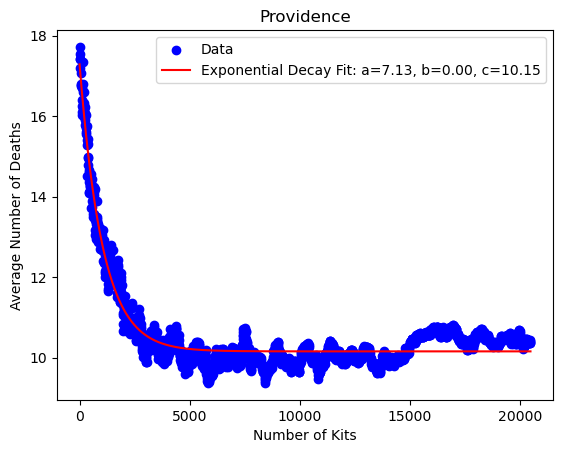

In [11]:
# Example Plot of Providence with Exponential Decay Function of best fit

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x_values_place = df_new.iloc[:, 0]  # First column (number of kits)
y_values_place = df_new.iloc[:, 1]  # Second column (average number of deaths)

x_values = np.array(x_values_place)
y_values = np.array(y_values_place)

# Define the exponential decay model with intercept: y = a * exp(-b * x) + c
def exp_decay_with_intercept(x, a, b, c):
    return a * np.exp(-b * x) + c

# Fit the exponential decay model with intercept to the data
params, covariance = curve_fit(exp_decay_with_intercept, x_values, y_values, p0=[y_values[0], 1, 0])

# Extract the fitted parameters a, b, and c
a, b, c = params
print(f"Fitted parameters: a = {a}, b = {b}, c = {c}")

# Generate the fitted values using the estimated parameters
y_fit = exp_decay_with_intercept(x_values, *params)

# Plot the data and the fitted exponential decay curve
plt.scatter(x_values, y_values, label='Data', color='blue')
plt.plot(x_values, y_fit, label=f'Exponential Decay Fit: a={a:.2f}, b={b:.2f}, c={c:.2f}', color='red')
plt.xlabel("Number of Kits")
plt.ylabel("Average Number of Deaths")
plt.title('Providence')  
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

import warnings
warnings.simplefilter("ignore")

# Assuming df_new is your original DataFrame
x_values_place = df_new.iloc[:, 0]  # First column (number of kits)
x_values = np.array(x_values_place)

# Define the exponential decay model with intercept: y = a * exp(-b * x) + c
def exp_decay_with_intercept(x, a, b, c):
    return a * np.exp(-b * x) + c

# Fit the exponential decay model to each city and collect the results
rows = []
for col_index in range(1, 40):  # df_new.iloc[:, 1] is the second column, and so on
    y_values_place = df_new.iloc[:, col_index]
    y_values = np.array(y_values_place)

    # Fit the exponential decay model with intercept to the data
    params, covariance = curve_fit(exp_decay_with_intercept, x_values, y_values, p0=[y_values[0], 1, 0])

    # Extract the fitted parameters a, b, and c
    a, b, c = params
    rows.append({"City": df_new.columns[col_index], "a": a, "b": b, "c": c})

# After looping, `results_df` contains the fitted parameters for all columns
results_df = pd.DataFrame(rows)
print(results_df)

# 3. Find Optimal Solution

Once each city is represented by its own exponential decay function, a greedy
algorithm allocates kits one at a time to whichever city currently has the
largest marginal decrease in projected deaths. Because each city's decay
function is independent of the others' allocations, this greedy approach is
guaranteed to reach the global optimum for this decomposed version of the
problem — unlike the neural network metamodel, which optimizes over the full
joint (and non-separable) simulation response.

In [ ]:
n = 39

x = np.zeros(n, dtype=int)
a = results_df['a'].to_numpy()
b = results_df['b'].to_numpy()
c = results_df['c'].to_numpy()

def y(i, x_i):
    return a[i] * np.exp(-b[i] * x_i) + c[i]

# Greedy allocation of the full 50,000-kit statewide budget
total_kits = 50000
for _ in range(total_kits):
    # Compute marginal decrease for each city
    deltas = [y(i, x[i] + 1) - y(i, x[i]) for i in range(n)]
    best_city = np.argmin(deltas)
    x[best_city] += 1

# Final allocation
results_df['kits'] = x
results_df['final_output'] = [y(i, x[i]) for i in range(n)]
print(results_df[['City', 'kits', 'final_output']])
print("Total final output:", sum(results_df['final_output']))


In [18]:
new_df = pd.DataFrame([results_df['kits'].values], columns=results_df['City'].values)
print(new_df)

   Barrington  Bristol  Burrillville  Central.Falls  Charlestown  Coventry  \
0         807     1606           759           1157           46      1911   

   Cranston  Cumberland  East.Greenwich  East.Providence  ...  Scituate  \
0      4273        2144             584             2044  ...       274   

   Smithfield  South.Kingstown  Tiverton  Warren  Warwick  West.Greenwich  \
0        1449             1032       758      67     3710             392   

   West.Warwick  Westerly  Woonsocket  
0          1356       802        1347  

[1 rows x 39 columns]


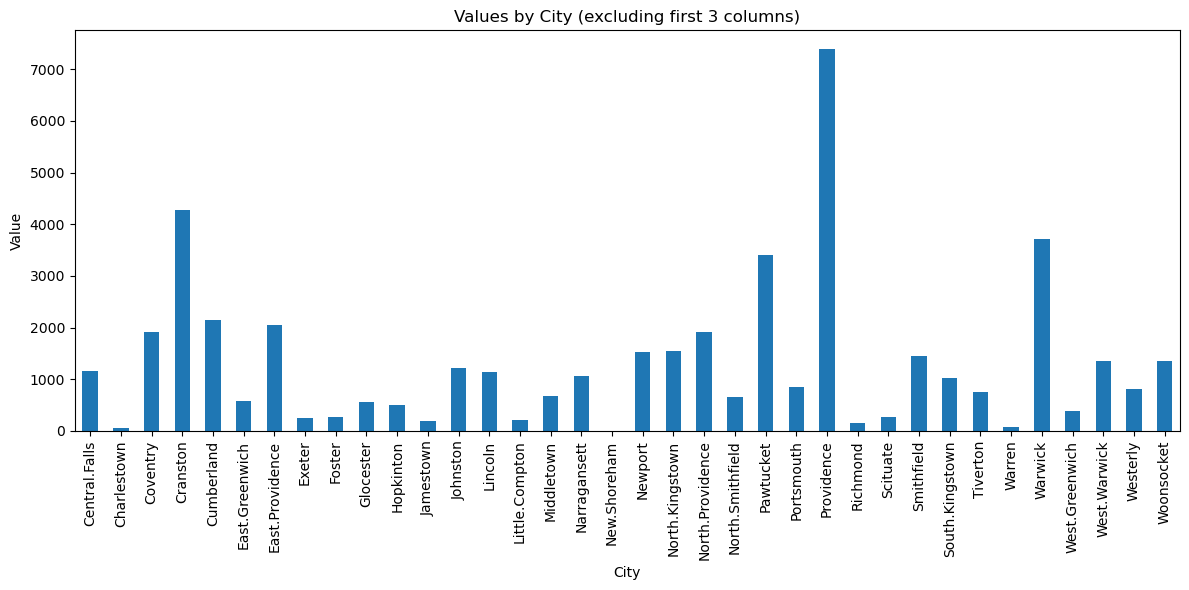

In [20]:
import matplotlib.pyplot as plt

# Take the first row and exclude the first 3 columns
data = new_df.iloc[0, 3:]

# Plot
plt.figure(figsize=(12,6))
data.plot(kind='bar')

plt.title('Values by City (excluding first 3 columns)')
plt.xlabel('City')
plt.ylabel('Value')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [51]:
df_repeated = pd.concat([new_df] * 100, ignore_index=True)
print(df_repeated)

    Barrington  Bristol  Burrillville  Central.Falls  Charlestown  Coventry  \
0          807     1606           759           1157           46      1911   
1          807     1606           759           1157           46      1911   
2          807     1606           759           1157           46      1911   
3          807     1606           759           1157           46      1911   
4          807     1606           759           1157           46      1911   
..         ...      ...           ...            ...          ...       ...   
95         807     1606           759           1157           46      1911   
96         807     1606           759           1157           46      1911   
97         807     1606           759           1157           46      1911   
98         807     1606           759           1157           46      1911   
99         807     1606           759           1157           46      1911   

    Cranston  Cumberland  East.Greenwich  East.Prov

In [ ]:
from pathlib import Path

# Repo root (1 level up from notebooks/)
BASE_DIR = Path.cwd().parents[0]
output_dir = BASE_DIR / "results" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

file_path = output_dir / "greedy_solution_distribution.csv"

In [ ]:
print(file_path)

In [60]:
# Export to a CSV
df_repeated.to_csv(file_path)

`df_repeated` is the greedy algorithm's proposed allocation, duplicated across
the 100 calibrated parameter seeds. This was run back through the actual
simulation on the HPC cluster to get ground-truth projected deaths for this
allocation, rather than relying on the exponential-decay approximation alone.

# Code to get average Deaths from results

In [ ]:
# NOTE: This assumes the re-simulation step (executed on the HPC cluster) has
# already produced greedy_solution_distribution_deaths.csv.
from pathlib import Path

# Repo root (1 level up from notebooks/)
BASE_DIR = Path.cwd().parents[0]
file_path = BASE_DIR / "results" / "outputs" / "greedy_solution_distribution_deaths.csv"

In [66]:
# Import the final results:

# Read CSV file
new_df = pd.read_csv(file_path)
new_df = new_df.iloc[:, 1:]
print(new_df)

    od_death_2024  od_death_2025  od_death_2026  Barrington  Bristol  \
0             345            308            308         807     1606   
1             354            346            345         807     1606   
2             326            309            324         807     1606   
3             321            304            325         807     1606   
4             284            272            270         807     1606   
..            ...            ...            ...         ...      ...   
95            359            378            387         807     1606   
96            313            350            331         807     1606   
97            344            320            318         807     1606   
98            363            367            375         807     1606   
99            307            318            277         807     1606   

    Burrillville  Central.Falls  Charlestown  Coventry  Cranston  ...  \
0            759           1157           46      1911      42

In [ ]:
average = new_df.iloc[:100, 2].mean()
print(f"Projected number of deaths from the greedy algorithm distribution: {average}")

From the simulation code, this new solution predicts **342.79 projected deaths**

In [112]:
# Save the results here to be used later

# Keep only the first row and all columns except the first 3
greedy_algo_results = new_df.iloc[[0], 3:].copy()

# Insert the new column at the beginning
greedy_algo_results.insert(0, "od_death_2026", average)

greedy_algo_results

,od_death_2026,Barrington,Bristol,Burrillville,Central.Falls,Charlestown,Coventry,Cranston,Cumberland,East.Greenwich,...,Scituate,Smithfield,South.Kingstown,Tiverton,Warren,Warwick,West.Greenwich,West.Warwick,Westerly,Woonsocket
0,342.79,807,1606,759,1157,46,1911,4273,2144,584,...,274,1449,1032,758,67,3710,392,1356,802,1347


In [ ]:
from pathlib import Path

# Repo root (1 level up from notebooks/)
BASE_DIR = Path.cwd().parents[0]
output_dir = BASE_DIR / "results" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

file_path = output_dir / "greedy_algo_results.csv"
file_path

In [117]:
# Export to a CSV
greedy_algo_results.to_csv(file_path)